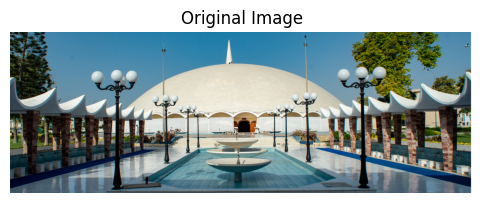

For k = 20:
Actual Image Size: 585000 pixels
Compressed Image Size: 35020 elements
Compression Ratio: 16.70

For k = 40:
Actual Image Size: 585000 pixels
Compressed Image Size: 70040 elements
Compression Ratio: 8.35

For k = 60:
Actual Image Size: 585000 pixels
Compressed Image Size: 105060 elements
Compression Ratio: 5.57

For k = 80:
Actual Image Size: 585000 pixels
Compressed Image Size: 140080 elements
Compression Ratio: 4.18

For k = 100:
Actual Image Size: 585000 pixels
Compressed Image Size: 175100 elements
Compression Ratio: 3.34



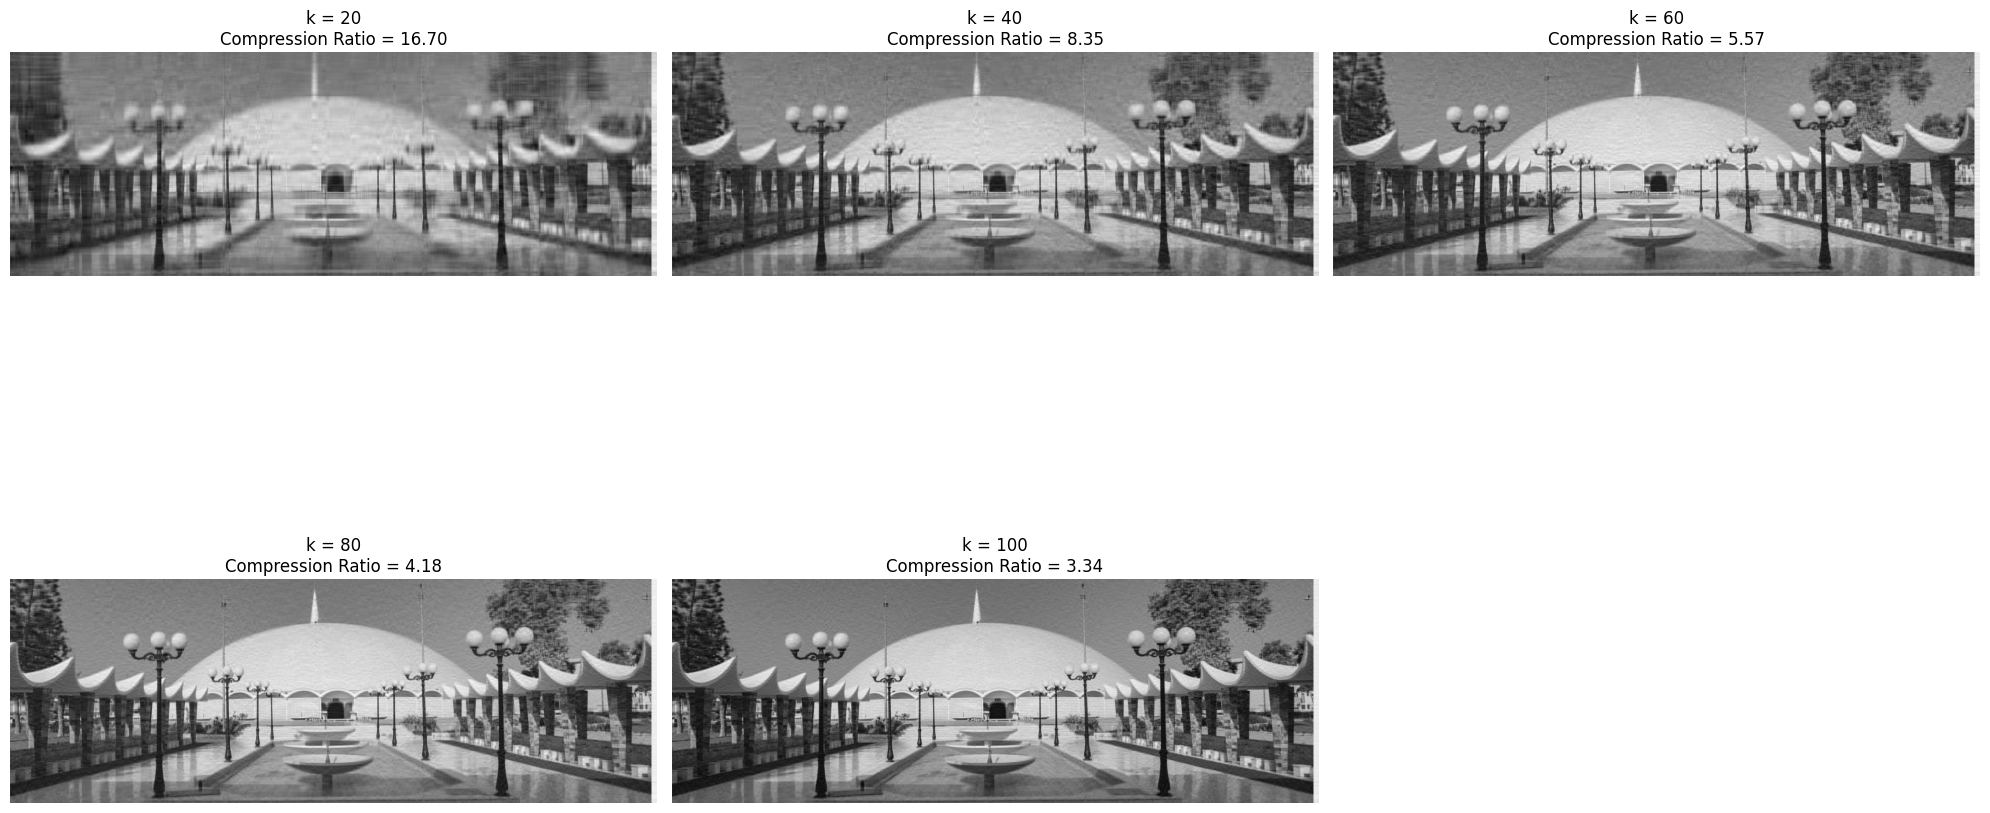

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

# Load the image
image_path = "/content/masjid e tooba.png"  # Replace with your image path
image = io.imread(image_path)

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

# Convert to grayscale (handling alpha channel if present)
if image.shape[-1] == 4:  # Check if image has an alpha channel
    image = color.rgba2rgb(image)

image_grey = color.rgb2gray(image)

# Perform SVD
U, S, Vt = np.linalg.svd(image_grey, full_matrices=False)

# Function to reconstruct image with k singular values
def reconstruct_image(U, S, Vt, k):
    S_k = np.zeros((k, k))
    np.fill_diagonal(S_k, S[:k])
    U_k = U[:, :k]
    Vt_k = Vt[:k, :]
    return np.dot(U_k, np.dot(S_k, Vt_k))

# Function to calculate sizes
def calculate_sizes(U, Vt, k):
    original_size = U.shape[0] * Vt.shape[1]  # Original size (pixels)
    compressed_size = k * (U.shape[0] + Vt.shape[1]) + k  # Compressed size
    return original_size, compressed_size

# Values of k to test
k_values = [20, 40, 60,80,100]

# Plot original and reconstructed images
plt.figure(figsize=(20, 12))

for i, k in enumerate(k_values):
    compressed_image = reconstruct_image(U, S, Vt, k)

    # Calculate sizes and compression ratio
    original_size, compressed_size = calculate_sizes(U, Vt, k)
    compression_ratio = (original_size / compressed_size)

    # Print sizes and compression ratio
    print(f"For k = {k}:")
    print(f"Actual Image Size: {original_size} pixels")
    print(f"Compressed Image Size: {compressed_size} elements")
    print(f"Compression Ratio: {compression_ratio:.2f}\n")

    # Display the reconstructed images
    plt.subplot(2, 3, i + 1)
    plt.imshow(compressed_image, cmap='gray')
    plt.title(f"k = {k}\nCompression Ratio = {compression_ratio:.2f}")
    plt.axis('off')


plt.tight_layout()
plt.show()


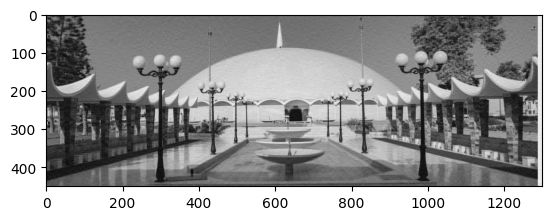

In [ ]:
k=100 # choose top k as per the clarity (least compression rate = 3%)
compressed_image = reconstruct_image(U, S, Vt, k)
plt.imshow(compressed_image, cmap='gray')

